In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset FIRST
df = pd.read_csv("/content/Walmart Data Analysis and Forcasting.csv")

# 2. Convert to datetime, explicitly defining the Day-Month-Year format
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

# 3. Extract datetime features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

# 4. Drop the original Date column
# (Note: You may want to comment this out later if your forecasting models need the Date)
df.drop(columns=['Date'], inplace=True)

# 5. Display the DataFrame
df

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day
0,1,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,12
2,1,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,19
3,1,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,26
4,1,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,5
...,...,...,...,...,...,...,...,...,...,...
6430,45,713173.95,0,64.88,3.997,192.013558,8.684,2012,9,28
6431,45,733455.07,0,64.89,3.985,192.170412,8.667,2012,10,5
6432,45,734464.36,0,54.47,4.000,192.327265,8.667,2012,10,12
6433,45,718125.53,0,56.47,3.969,192.330854,8.667,2012,10,19


In [3]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 Store           0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Year            0
Month           0
Day             0
dtype: int64


In [4]:
print("\nSummary Statistics:\n", df.describe())


Summary Statistics:
              Store  Weekly_Sales  Holiday_Flag  Temperature   Fuel_Price  \
count  6435.000000  6.435000e+03   6435.000000  6435.000000  6435.000000   
mean     23.000000  1.046965e+06      0.069930    60.663782     3.358607   
std      12.988182  5.643666e+05      0.255049    18.444933     0.459020   
min       1.000000  2.099862e+05      0.000000    -2.060000     2.472000   
25%      12.000000  5.533501e+05      0.000000    47.460000     2.933000   
50%      23.000000  9.607460e+05      0.000000    62.670000     3.445000   
75%      34.000000  1.420159e+06      0.000000    74.940000     3.735000   
max      45.000000  3.818686e+06      1.000000   100.140000     4.468000   

               CPI  Unemployment         Year        Month          Day  
count  6435.000000   6435.000000  6435.000000  6435.000000  6435.000000  
mean    171.578394      7.999151  2010.965035     6.447552    15.678322  
std      39.356712      1.875885     0.797019     3.238308     8.755780

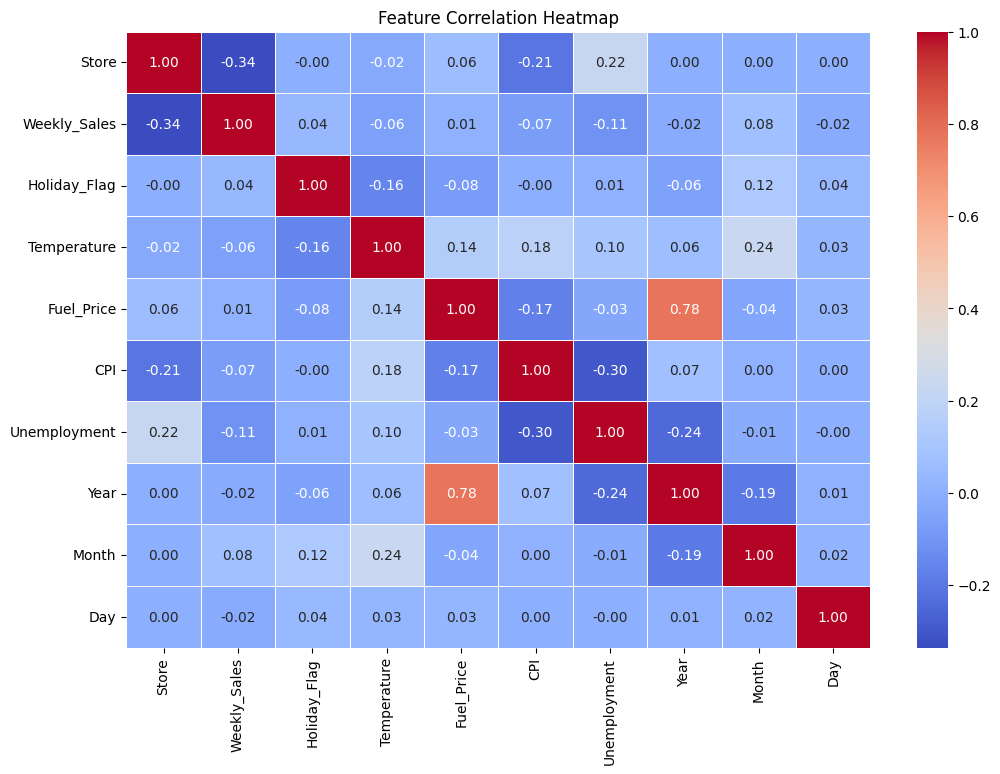

In [5]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Feature Correlation Heatmap")

plt.show()

DataFrame Columns: ['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day']


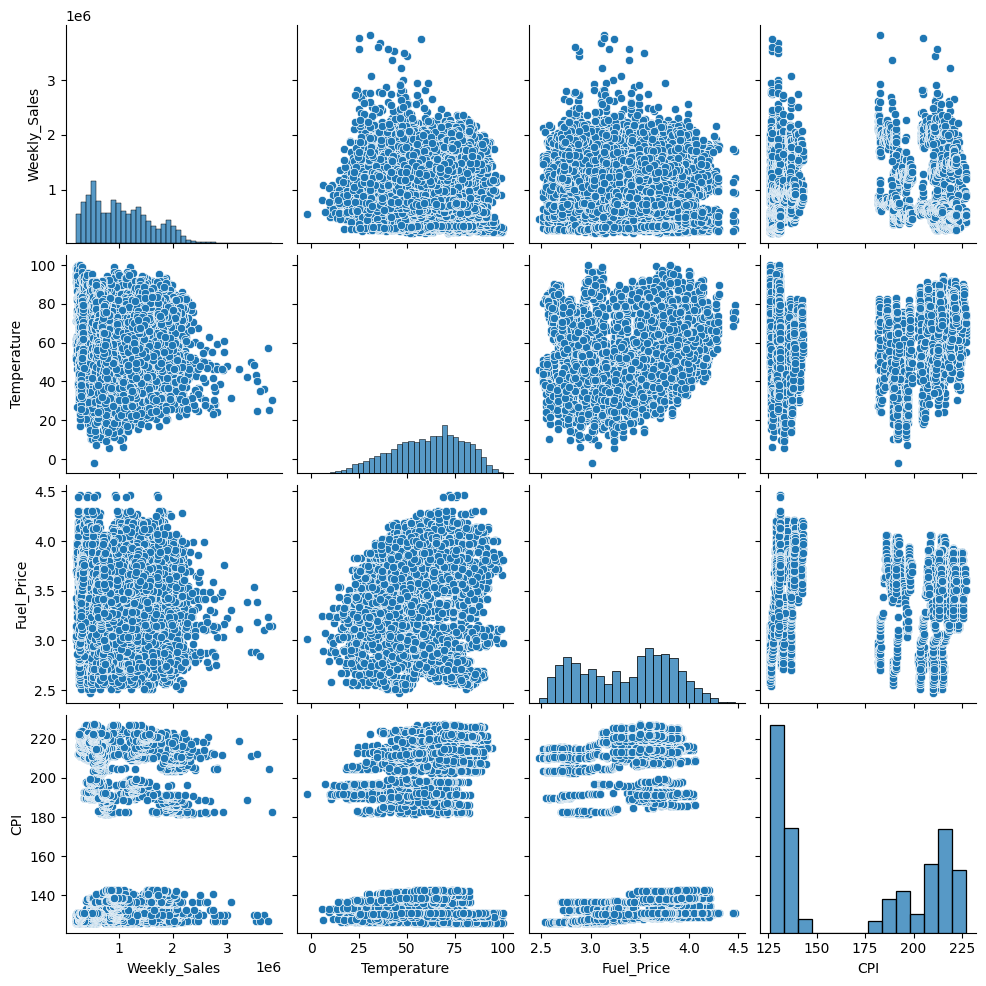

In [6]:
print("DataFrame Columns:", df.columns.tolist())

# Pairplot for key variables from the Walmart dataset
sns.pairplot(df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI']])
plt.show()

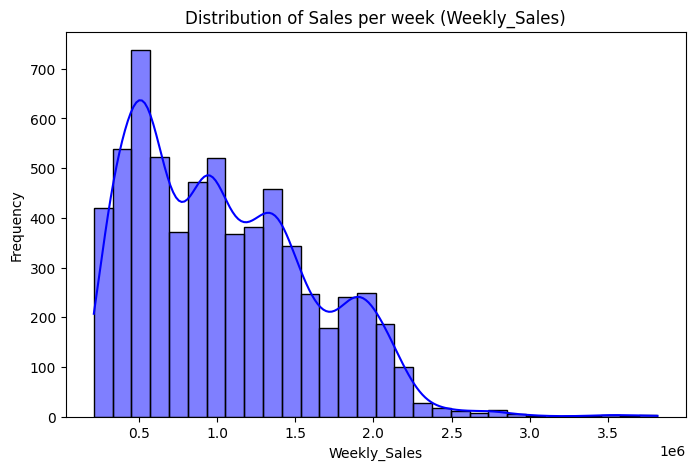

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Weekly_Sales'], bins=30, kde=True, color='blue')
plt.title("Distribution of Sales per week (Weekly_Sales)")
plt.xlabel("Weekly_Sales")
plt.ylabel("Frequency")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["Weekly_Sales"])  # All columns except target
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R2 Score: 0.1555
RMSE: 521597.6144


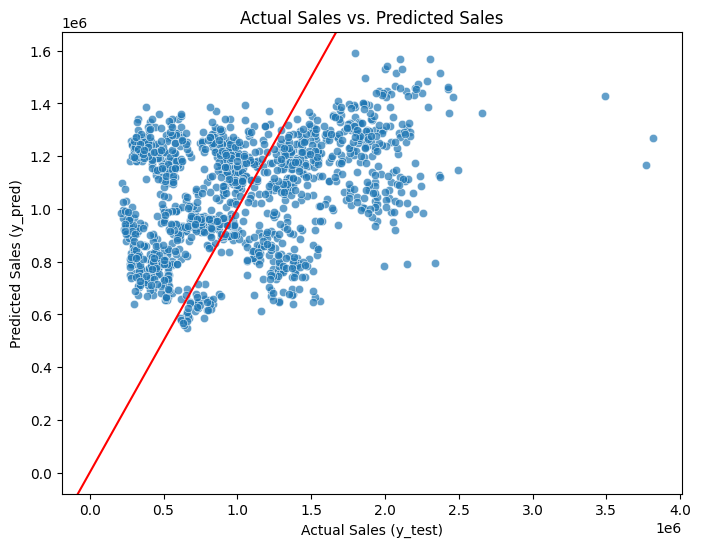

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel("Actual Sales (y_test)")
plt.ylabel("Predicted Sales (y_pred)")
plt.title("Actual Sales vs. Predicted Sales")
plt.axline([0,0],[1,1],color="red",linestyle='-')
plt.show()

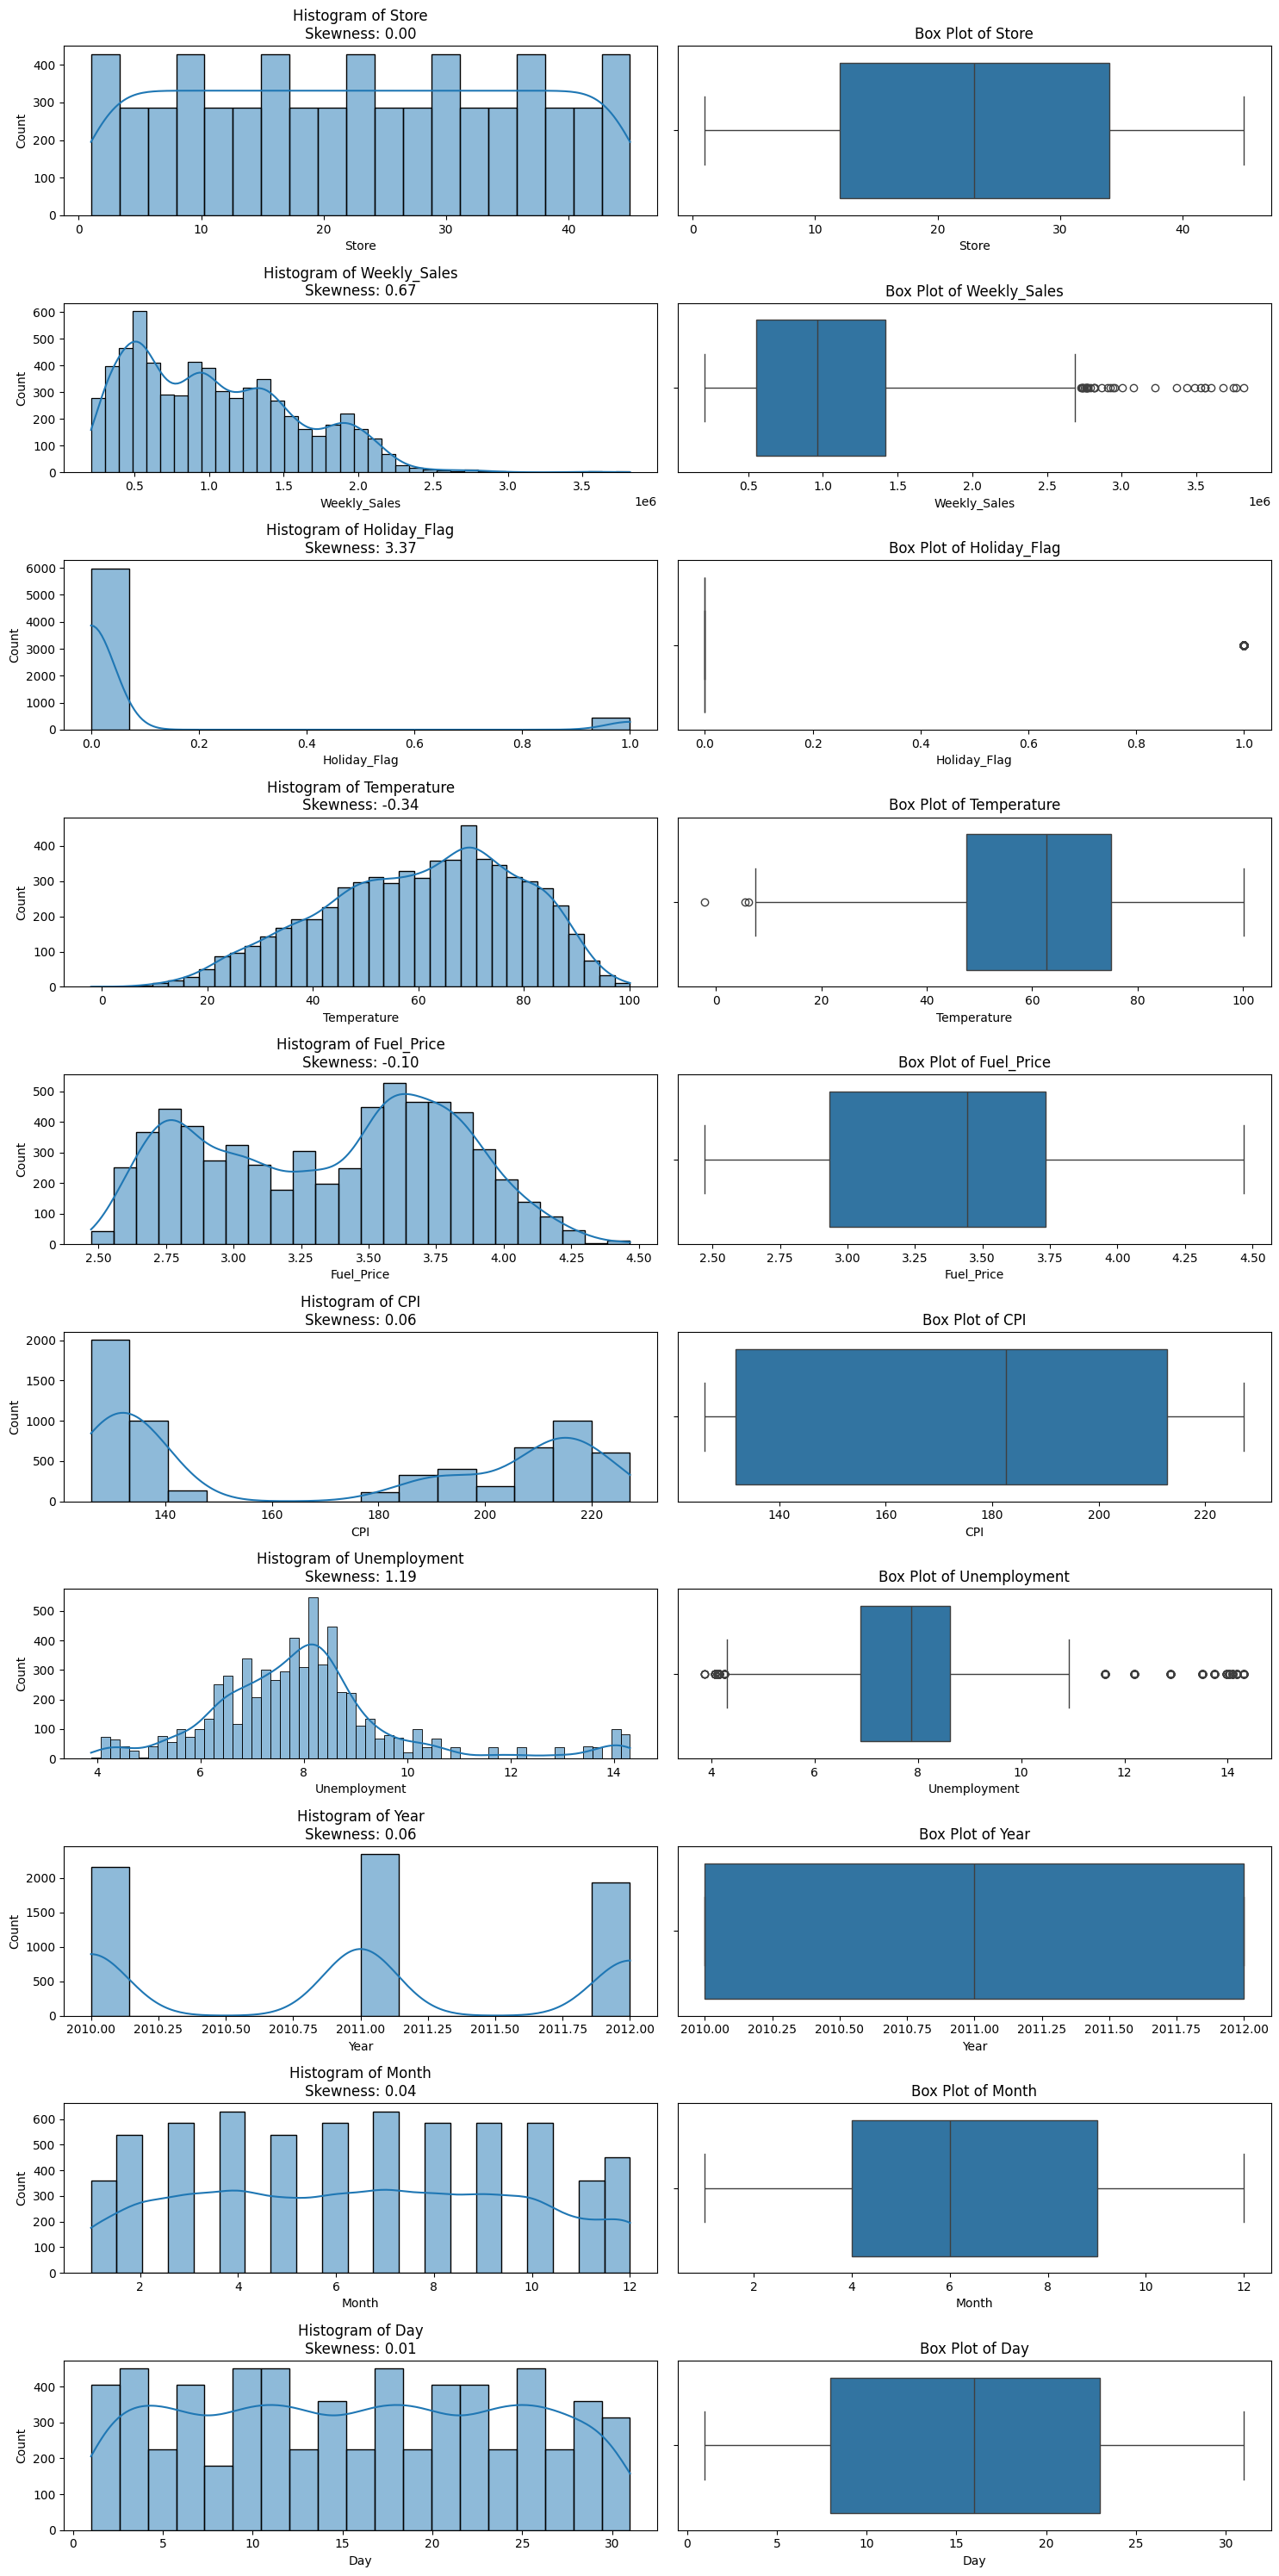

In [10]:
from scipy.stats import skew

skewness = df.skew()

num_cols = len(df.columns)
plt.figure(figsize=(15, num_cols * 3))

for i, col in enumerate(df.columns):
  plt.subplot(num_cols, 2, 2 * i + 1)
  sns.histplot(df[col], kde=True)
  plt.title(f"Histogram of {col}\nSkewness: {skewness[col]:.2f}")

  plt.subplot(num_cols, 2, 2 * i + 2)
  sns.boxplot(x=df[col])
  plt.title(f"Box Plot of {col}")

plt.tight_layout()

plt.show()

In [11]:
import numpy as np

#find higly skewed colums
skewed_cols = df.skew().abs()
highly_skewed = skewed_cols[skewed_cols > 1].index
negatively_skewed = skewed_cols[skewed_cols < 1].index
print("Highly Skewed Columns:\n",highly_skewed)
print("Negatively Skewed Columns:\n",negatively_skewed)

Highly Skewed Columns:
 Index(['Holiday_Flag', 'Unemployment'], dtype='object')
Negatively Skewed Columns:
 Index(['Store', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Year',
       'Month', 'Day'],
      dtype='object')


In [12]:
df[highly_skewed] = df[highly_skewed].apply(lambda x: np.log1p(x))

In [13]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
df[negatively_skewed] = pt.fit_transform(df[negatively_skewed])

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
X = df.drop(columns=["Weekly_Sales"])  # All columns except target
y = df["Weekly_Sales"]

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
r2 = r2_score(y_test, y_pred)
#rmse = mean_squared_error(y_test, y_pred, squared=False)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R2 Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R2 Score: 0.1336
RMSE: 0.9428


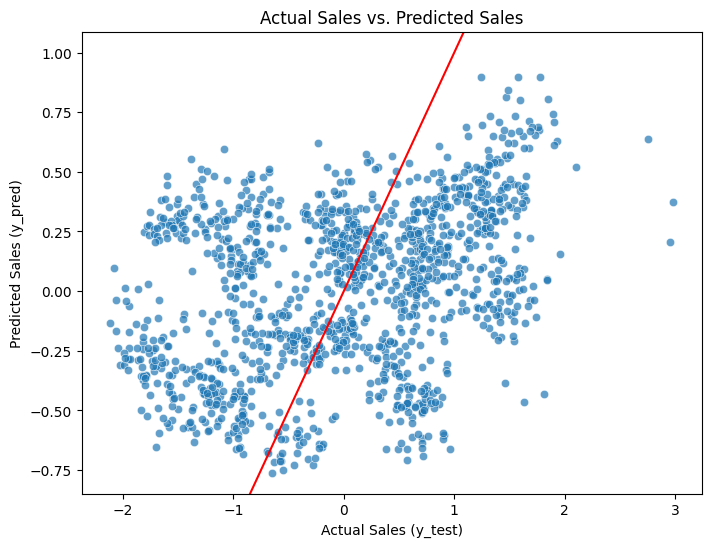

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel("Actual Sales (y_test)")
plt.ylabel("Predicted Sales (y_pred)")
plt.title("Actual Sales vs. Predicted Sales")
plt.axline([0,0],[1,1],color="red",linestyle='-')
plt.show()

In [16]:
from sklearn.ensemble import RandomForestRegressor

#Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

#Predictions
y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5

print(f"Random Forest R2 Score: {r2_rf:.4f}")
print(f"Random Forest RMSE: {rmse_rf:.4f}")

Random Forest R2 Score: 0.9762
Random Forest RMSE: 0.1563
